# E-Commerce-Sales Data Analysis
---

Work flow:-
1. Introduction 2. Dataset Overview 3. Data Cleaning 4. Feature Engineering 5. Product Analysis 6. Time Analysis 7. Business Insights 8. Conclusion

## Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data/Amazon Sale Report.csv', low_memory= False)

In [2]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [4]:
#Changing the data type of date
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/5m/y67y675x3hl3fdklb6p6mlnr0000gn/T/ipykernel_29266/779191431.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [5]:
summary = df.describe().drop(columns = ['index', 'ship-postal-code', 'Date'])
summary

,Qty,Amount
count,128975.000000,121180.000000
mean,0.904431,648.561465
min,0.000000,0.000000
25%,1.000000,449.000000
50%,1.000000,605.000000
75%,1.000000,788.000000
max,15.000000,5584.000000
std,0.313354,281.211687


In [6]:
df.shape

(128975, 24)

---
## Data Cleaning

##### Dealing with Na values

In [7]:
df.isna().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [8]:
df.isna().mean() * 100

index                  0.000000
Order ID               0.000000
Date                   0.000000
Status                 0.000000
Fulfilment             0.000000
Sales Channel          0.000000
ship-service-level     0.000000
Style                  0.000000
SKU                    0.000000
Category               0.000000
Size                   0.000000
ASIN                   0.000000
Courier Status         5.328164
Qty                    0.000000
currency               6.043807
Amount                 6.043807
ship-city              0.025586
ship-state             0.025586
ship-postal-code       0.025586
ship-country           0.025586
promotion-ids         38.110487
B2B                    0.000000
fulfilled-by          69.546811
Unnamed: 22           38.030626
dtype: float64

In [9]:
df.drop(columns = ['Unnamed: 22'], inplace = True)

<mark> Observation 1:- Unamed: 22 is a useless column for this analysis <mark>

In [10]:
na_amount = df[df['Amount'].isna() == True]
na_amount

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
8,8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,...,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
29,29,404-5933402-8801952,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,JNE2132,JNE2132-KR-398-XXXL,kurta,...,0,NaN,NaN,GUWAHATI,ASSAM,781003.0,IN,NaN,False,Easy Ship
65,65,171-4137548-0481151,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3373,JNE3373-KR-XXL,kurta,...,0,NaN,NaN,Dahod,Gujarat,389151.0,IN,NaN,False,NaN
84,84,403-9950518-0349133,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,kurta,...,0,NaN,NaN,HYDERABAD,TELANGANA,500072.0,IN,NaN,False,NaN
95,95,405-9112089-3379536,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-L,kurta,...,0,NaN,NaN,PUNE,MAHARASHTRA,411046.0,IN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128903,128903,406-3923120-4345139,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,JNE3801,JNE3801-KR-M,kurta,...,0,NaN,NaN,ANANTAPUR,ANDHRA PRADESH,515001.0,IN,NaN,False,NaN
128907,128907,403-6757403-6097100,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,NW014,NW014-ST-SR-XXXL,Set,...,0,NaN,NaN,GREATER NOIDA,UTTAR PRADESH,201306.0,IN,NaN,False,NaN
128908,128908,403-6757403-6097100,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,NW007,NW007-ST-CP-XXXL,Set,...,0,NaN,NaN,GREATER NOIDA,UTTAR PRADESH,201306.0,IN,NaN,False,NaN
128958,128958,408-9513596-4393945,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,SET058,SET058-KR-NP-L,Set,...,0,NaN,NaN,Bengaluru,KARNATAKA,560037.0,IN,NaN,False,NaN


In [11]:
non_cancel_na_amount = (df['Status'] != 'Cancelled') & (df['Amount'] == 'NaN')
df_non_cancel_na_amount = df[non_cancel_na_amount]
df_non_cancel_na_amount.size

0

<mark> Observation 2:- Every order with NaN amount value is a cancelled order <mark>

##### Finding and dealing with duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

<mark> Observation 3:- No duplicated values exist <mark>

### Conclusion of Data cleaning :- 
- Unamed: 22 column is of no use
- Every order with NaN amount value is a cancelled order
- No duplicates exist

---
## Feature Engeineering

Here I'll be adding 4 new features which will make our analysis much better

In [13]:
#Revenue Feature 
df['Revenue'] = df['Amount'] * df['Qty']

In [14]:
#Year Feature
df['Year'] = df['Date'].dt.year

In [15]:
#Month Feature
df['Month'] = df['Date'].dt.month_name()

In [16]:
#order size feature
#Any order with revenue over 30000 is a large order and any order below 30000 is a small order
df['Order-size'] = df['Revenue'].apply(lambda x: 'Large' if x>3000 else 'Small')

---
## Product analysis

In [17]:
#- Category-wise revenue
#- Category-wise units sold
#- Most expensive SKUs
#- High volume but low revenue SKUs

In [18]:
cate_sales = df.groupby('Category')['Revenue'].sum()
cate_sales.sort_values(ascending = False)

Category
Set              37934434.0
kurta            20675349.0
Western Dress    10707932.0
Top               5242931.0
Ethnic Dress       762949.0
Blouse             441259.0
Bottom             142870.0
Saree              125767.0
Dupatta               915.0
Name: Revenue, dtype: float64

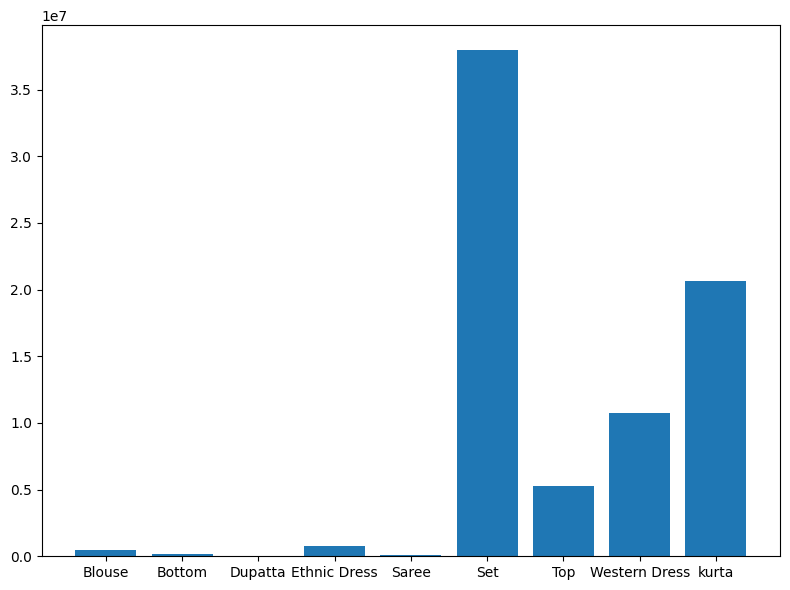

In [33]:
plt.figure(figsize=(8,6))
plt.bar(cate_sales.index, cate_sales.values)
plt.tight_layout()
plt.show()